In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats 

In [3]:
equip_no_rep_clean_kpi = pd.read_csv("../DATA/equip_no_rep_clean_kpi.csv")
equip_rep_clean_kpi = pd.read_csv("../DATA/equip_rep_clean_kpi.csv")

c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



RESULTADOS DE LA PRUEBA T-STUDENT
                Variable  Mean_no_rep  Std_no_rep   Mean_rep   Std_rep  Difference  n_no_rep  n_rep  t_statistic       p_value Significant
          precision_tiro    33.799746   16.002352  39.774748 14.779504    5.975001       609    872    -7.397842  2.309972e-13          Si
aprovechamiento_posesion     0.258423    0.102157   0.266832  0.094476    0.008409       609    872    -1.629784  1.033601e-01          No
    peligrosidad_centros     0.000412    0.000577   0.000944  0.000639    0.000532       609    872   -16.409934  1.002377e-55          Si
      limpieza_defensiva    40.264612   12.639235  41.856444 12.907388    1.591832       609    872    -2.355322  1.863666e-02          Si
     efectividad_despeje   100.000000    0.000000 100.000000  0.000000    0.000000       609    872          NaN           NaN          No
     indice_verticalidad    36.440026  414.888051   7.876813  3.326943  -28.563213       609    872     2.033189  4.221167e-02     

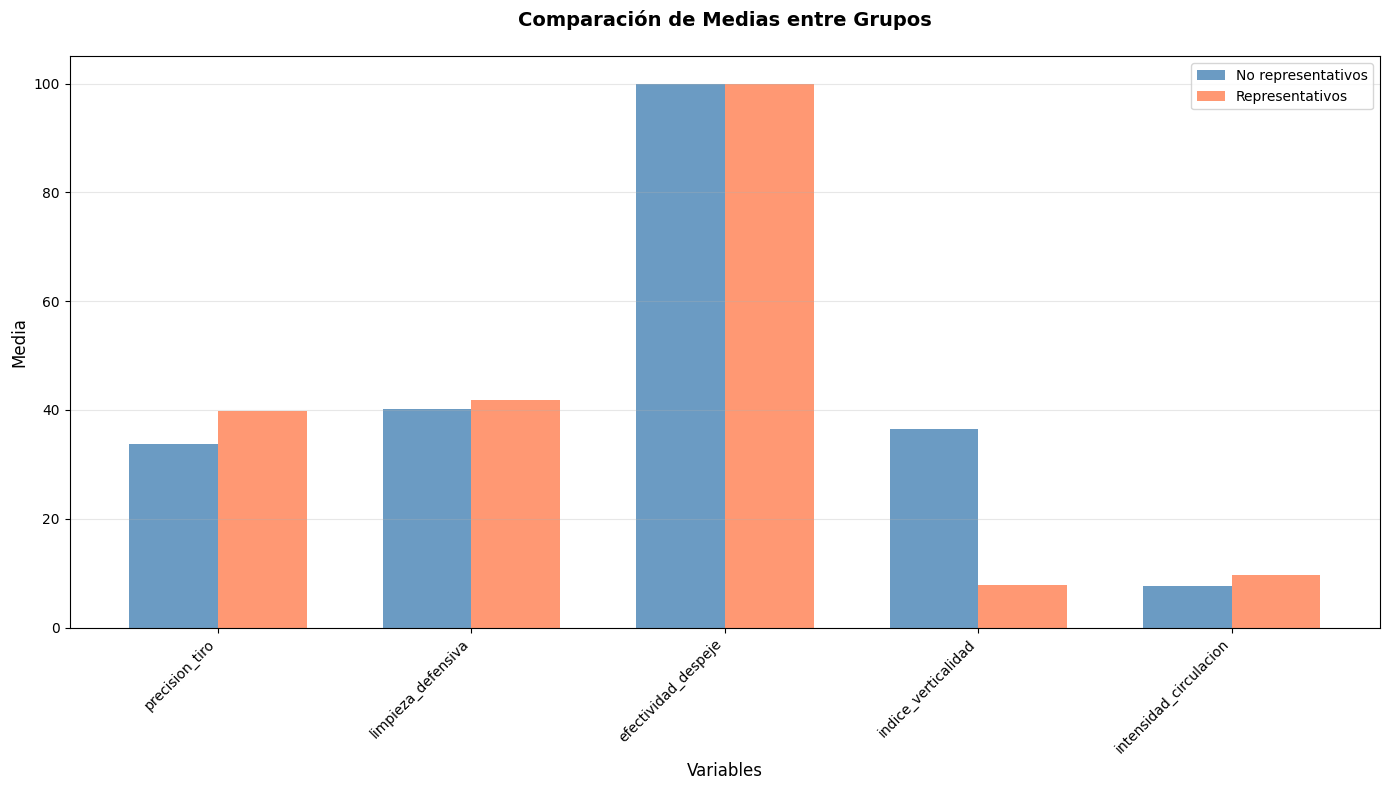

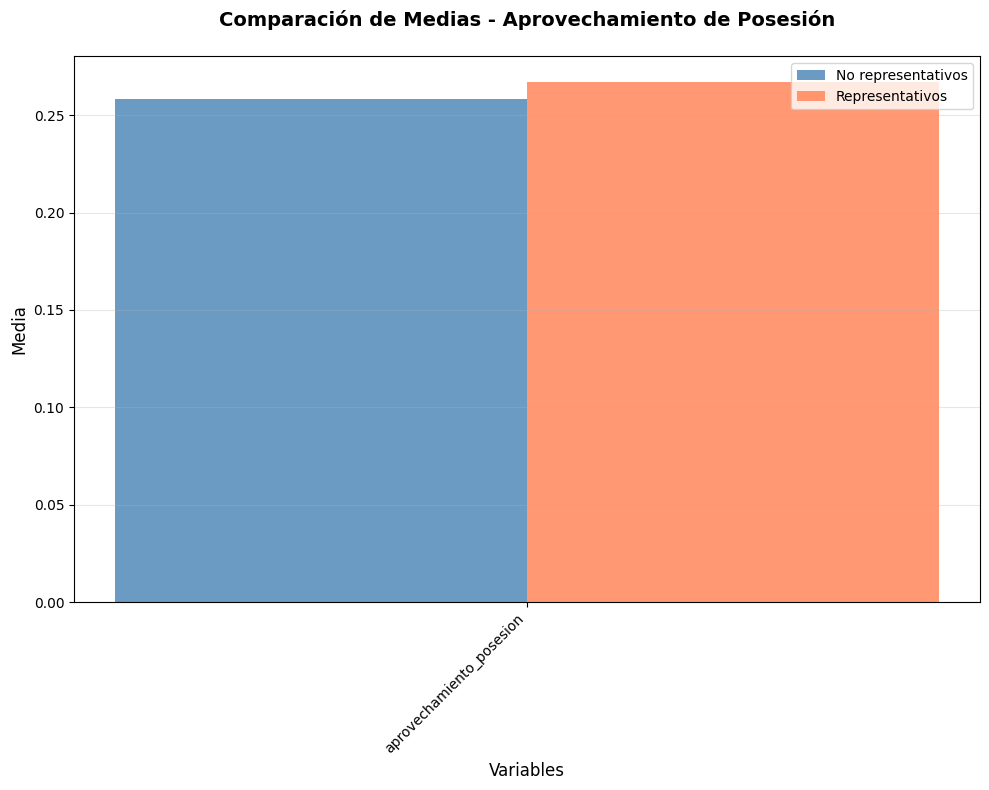

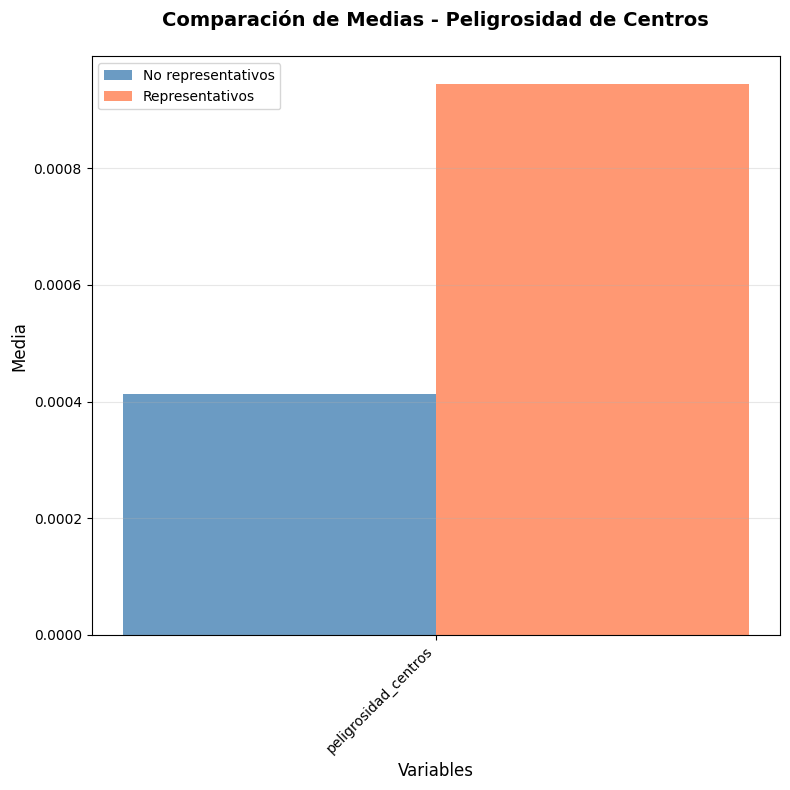


✓ Gráficos guardados en la carpeta '../images/'
✓ Tablas LaTeX guardadas en la carpeta '../tables/':
  - t_test_complete.tex (tabla completa)
  - t_test_summary.tex (tabla resumida)
  - t_test_significant.tex (solo resultados significativos)
  - t_test_results.csv (datos en CSV)


In [6]:
# Separate columns by scale
large_scale_cols = [
    'precision_tiro',
    'precision_centros',
    'limpieza_defensiva',
    'limpieza_defensiva_completa',
    'efectividad_despeje',
    'indice_verticalidad',
    'verticalidad_efectiva',
    'precision_verticalidad',
    'intensidad_circulacion',
    'intensidad_circulacion_precisa'
]

aprovechamiento_cols = [
    'aprovechamiento_posesion',
    'aprovechamiento_posesion_peligroso'
]

peligrosidad_cols = [
    'peligrosidad_centros'
]

# Perform t-tests and store results
results = []
for col in columns_to_compare:
    # Get data from both dataframes
    data1 = equip_no_rep_clean_kpi[col].dropna()
    data2 = equip_rep_clean_kpi[col].dropna()
    
    # Perform independent t-test
    t_stat, p_value = stats.ttest_ind(data1, data2)
    
    # Calculate means and standard deviations
    mean1 = data1.mean()
    mean2 = data2.mean()
    std1 = data1.std()
    std2 = data2.std()
    
    results.append({
        'Variable': col,
        'Mean_no_rep': mean1,
        'Std_no_rep': std1,
        'Mean_rep': mean2,
        'Std_rep': std2,
        'Difference': mean2 - mean1,
        'n_no_rep': len(data1),
        'n_rep': len(data2),
        't_statistic': t_stat,
        'p_value': p_value,
        'Significant': 'Si' if p_value < 0.05 else 'No'
    })

# Create results dataframe
results_df = pd.DataFrame(results)

# Print the comparison results
print("\n" + "="*80)
print("RESULTADOS DE LA PRUEBA T-STUDENT")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)
print("RESULTADOS SIGNIFICATIVOS (p < 0.05)")
print("="*80)
significant_df = results_df[results_df['Significant'] == 'Yes']
if len(significant_df) > 0:
    print(significant_df[['Variable', 'Mean_no_rep', 'Mean_rep', 'Difference', 'p_value']].to_string(index=False))
else:
    print("No se encontraron diferencias significativas")
print("="*80 + "\n")

# Save results to CSV
results_df.to_csv('../tables/t_test_results.csv', index=False)

# Create a formatted table for LaTeX - Complete results
latex_df = results_df.copy()
latex_df = latex_df.round({
    'Mean_no_rep': 3,
    'Std_no_rep': 3,
    'Mean_rep': 3,
    'Std_rep': 3,
    'Difference': 3,
    't_statistic': 3,
    'p_value': 4
})

# Rename columns to avoid underscore issues in LaTeX
latex_df.columns = [
    'Variable', 'Mean no rep', 'Std no rep', 'Mean rep', 'Std rep', 
    'Difference', 'n no rep', 'n rep', 't statistic', 'p value', 'Significant'
]

# Save complete table as LaTeX
with open('../tables/t_test_complete.tex', 'w') as f:
    # Replace underscores in variable names
    latex_df['Variable'] = latex_df['Variable'].str.replace('_', ' ')
    
    latex_table = latex_df.to_latex(
        index=False,
        caption='Resultados completos de la prueba t-Student',
        label='tab:ttest_complete',
        column_format='lrrrrrrrrrr',  # Changed to right-aligned for numbers
        escape=True
    )
    
    # Wrap the entire table in resizebox
    latex_with_resize = latex_table.replace(
        r'\begin{tabular}',
        r'\resizebox{\textwidth}{!}{%' + '\n' + r'\begin{tabular}'
    ).replace(
        r'\end{tabular}',
        r'\end{tabular}' + '\n' + r'}'
    )
    
    f.write(latex_with_resize)
    

# Create a simplified table for LaTeX - Summary
summary_df = results_df[['Variable', 'Mean_no_rep', 'Mean_rep', 'Difference', 't_statistic', 'p_value', 'Significant']].copy()
summary_df = summary_df.round({
    'Mean_no_rep': 3,
    'Mean_rep': 3,
    'Difference': 3,
    't_statistic': 3,
    'p_value': 4
})

# Rename columns to avoid underscore issues in LaTeX
summary_df.columns = [
    'Variable', 'Mean no rep', 'Mean rep', 'Difference', 
    't statistic', 'p value', 'Significant'
]

with open('../tables/t_test_summary.tex', 'w') as f:
    latex_table = summary_df.to_latex(
        index=False,
        caption='Resumen de resultados de la prueba t-Student',
        label='tab:ttest_summary',
        column_format='lcccccc',
        escape=True  # Changed to True
    )
    f.write(latex_table)


# Create table with only significant results
if len(significant_df) > 0:
    significant_summary = significant_df[['Variable', 'Mean_no_rep', 'Mean_rep', 'Difference', 't_statistic', 'p_value']].copy()
    significant_summary = significant_summary.round({
        'Mean_no_rep': 3,
        'Mean_rep': 3,
        'Difference': 3,
        't_statistic': 3,
        'p_value': 4
    })
    
    # Replace underscores in variable names
    significant_summary['Variable'] = significant_summary['Variable'].str.replace('_', ' ')
    
    # Rename columns to avoid underscore issues in LaTeX
    significant_summary.columns = [
        'Variable', 
        'Mean no rep', 
        'Mean rep', 
        'Difference', 
        't statistic', 
        'p value'
    ]
    
    with open('../tables/t_test_significant.tex', 'w') as f:
        latex_table = significant_summary.to_latex(
            index=False,
            caption='Resultados significativos de la prueba t-Student (p < 0.05)',
            label='tab:ttest_significant',
            column_format='lrrrrr',
            escape=True
        )
        
        # Add \small before tabular
        latex_with_small = latex_table.replace(
            r'\begin{tabular}',
            r'\small' + '\n' + r'\begin{tabular}'
        )
        
        f.write(latex_with_small)

# PLOT 1: Large scale variables
large_results = results_df[results_df['Variable'].isin(large_scale_cols)]

if len(large_results) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(large_results))
    width = 0.35
    
    means_no_rep = large_results['Mean_no_rep'].values
    means_rep = large_results['Mean_rep'].values
    
    bars1 = ax.bar(x - width/2, means_no_rep, width, label='No representativos', 
                  alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, means_rep, width, label='Representativos', 
                  alpha=0.8, color='coral')
    
    # Add significance markers
    for i, (idx, row) in enumerate(large_results.iterrows()):
        if row['Significant'] == 'Yes':
            max_height = max(row['Mean_no_rep'], row['Mean_rep'])
            ax.text(i, max_height * 1.05, '*', ha='center', 
                   fontsize=16, fontweight='bold', color='red')
    
    ax.set_xlabel('Variables', fontsize=12)
    ax.set_ylabel('Media', fontsize=12)
    ax.set_title('Comparación de Medias entre Grupos\n', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(large_results['Variable'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparison_barplot_large_scale.png', dpi=300, bbox_inches='tight')
    plt.show()

# PLOT 2: Aprovechamiento variables
aprovechamiento_results = results_df[results_df['Variable'].isin(aprovechamiento_cols)]

if len(aprovechamiento_results) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    x = np.arange(len(aprovechamiento_results))
    width = 0.35
    
    means_no_rep = aprovechamiento_results['Mean_no_rep'].values
    means_rep = aprovechamiento_results['Mean_rep'].values
    
    bars1 = ax.bar(x - width/2, means_no_rep, width, label='No representativos', 
                  alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, means_rep, width, label='Representativos', 
                  alpha=0.8, color='coral')
    
    # Add significance markers
    for i, (idx, row) in enumerate(aprovechamiento_results.iterrows()):
        if row['Significant'] == 'Yes':
            max_height = max(row['Mean_no_rep'], row['Mean_rep'])
            ax.text(i, max_height * 1.05, '*', ha='center', 
                   fontsize=16, fontweight='bold', color='red')
    
    ax.set_xlabel('Variables', fontsize=12)
    ax.set_ylabel('Media', fontsize=12)
    ax.set_title('Comparación de Medias - Aprovechamiento de Posesión\n', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(aprovechamiento_results['Variable'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparison_barplot_aprovechamiento.png', dpi=300, bbox_inches='tight')
    plt.show()

# PLOT 3: Peligrosidad centros
peligrosidad_results = results_df[results_df['Variable'].isin(peligrosidad_cols)]

if len(peligrosidad_results) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    x = np.arange(len(peligrosidad_results))
    width = 0.35
    
    means_no_rep = peligrosidad_results['Mean_no_rep'].values
    means_rep = peligrosidad_results['Mean_rep'].values
    
    bars1 = ax.bar(x - width/2, means_no_rep, width, label='No representativos', 
                  alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, means_rep, width, label='Representativos', 
                  alpha=0.8, color='coral')
    
    # Add significance markers
    for i, (idx, row) in enumerate(peligrosidad_results.iterrows()):
        if row['Significant'] == 'Yes':
            max_height = max(row['Mean_no_rep'], row['Mean_rep'])
            ax.text(i, max_height * 1.05, '*', ha='center', 
                   fontsize=16, fontweight='bold', color='red')
    
    ax.set_xlabel('Variables', fontsize=12)
    ax.set_ylabel('Media', fontsize=12)
    ax.set_title('Comparación de Medias - Peligrosidad de Centros\n', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(peligrosidad_results['Variable'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparison_barplot_peligrosidad.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n✓ Gráficos guardados en la carpeta '../images/'")
print("✓ Tablas LaTeX guardadas en la carpeta '../tables/':")
print("  - t_test_complete.tex (tabla completa)")
print("  - t_test_summary.tex (tabla resumida)")
print("  - t_test_significant.tex (solo resultados significativos)")
print("  - t_test_results.csv (datos en CSV)")

c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


                   Variable  Mean_no_rep    Mean_rep  Difference  t_statistic  \
0            precision_tiro    33.799746   39.774748    5.975001    -7.397842   
1  aprovechamiento_posesion     0.258423    0.266832    0.008409    -1.629784   
2      peligrosidad_centros     0.000412    0.000944    0.000532   -16.409934   
3        limpieza_defensiva    40.264612   41.856444    1.591832    -2.355322   
4       efectividad_despeje   100.000000  100.000000    0.000000          NaN   
5       indice_verticalidad    36.440026    7.876813  -28.563213     2.033189   
6    intensidad_circulacion     7.614551    9.638272    2.023721   -25.211788   

         p_value Significant  
0   2.309972e-13         Yes  
1   1.033601e-01          No  
2   1.002377e-55         Yes  
3   1.863666e-02         Yes  
4            NaN          No  
5   4.221167e-02         Yes  
6  5.717460e-117         Yes  


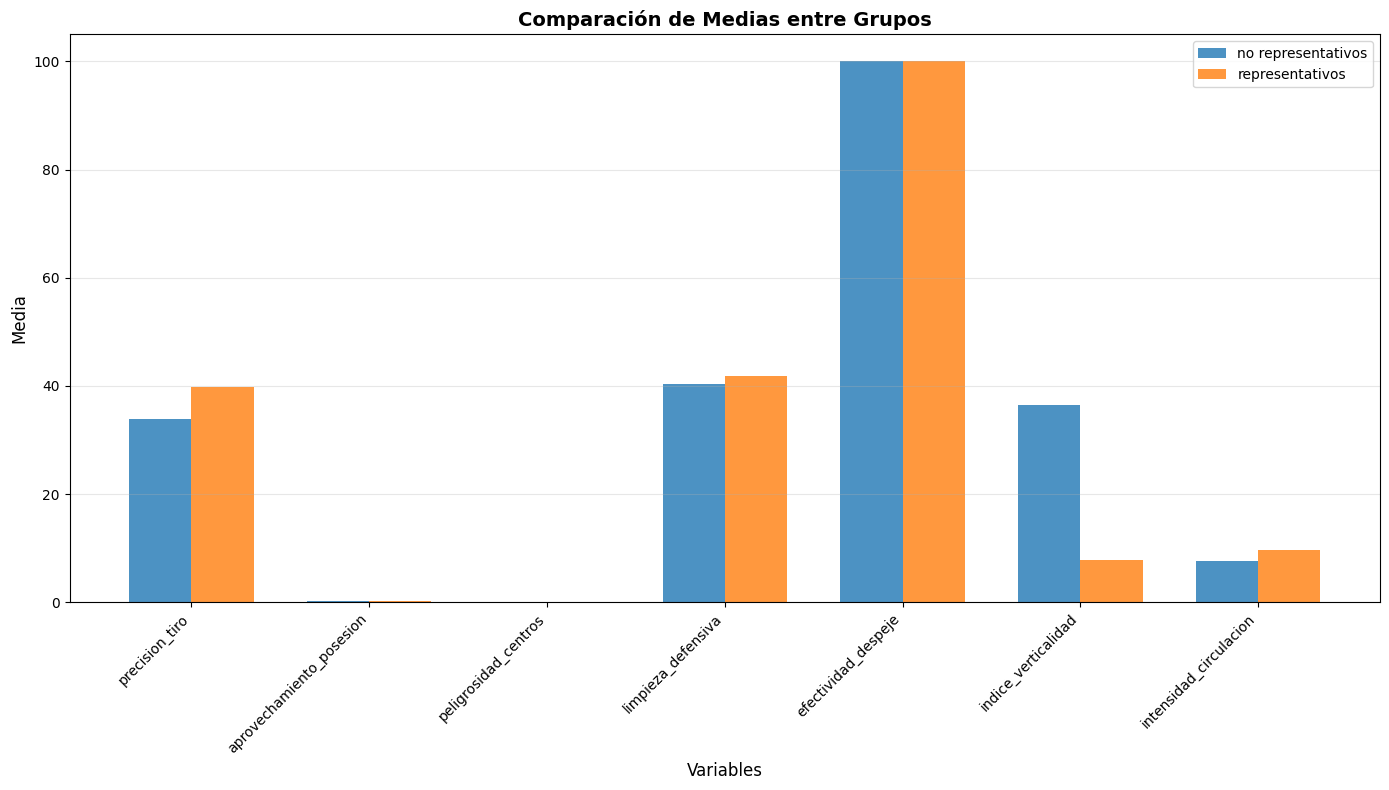

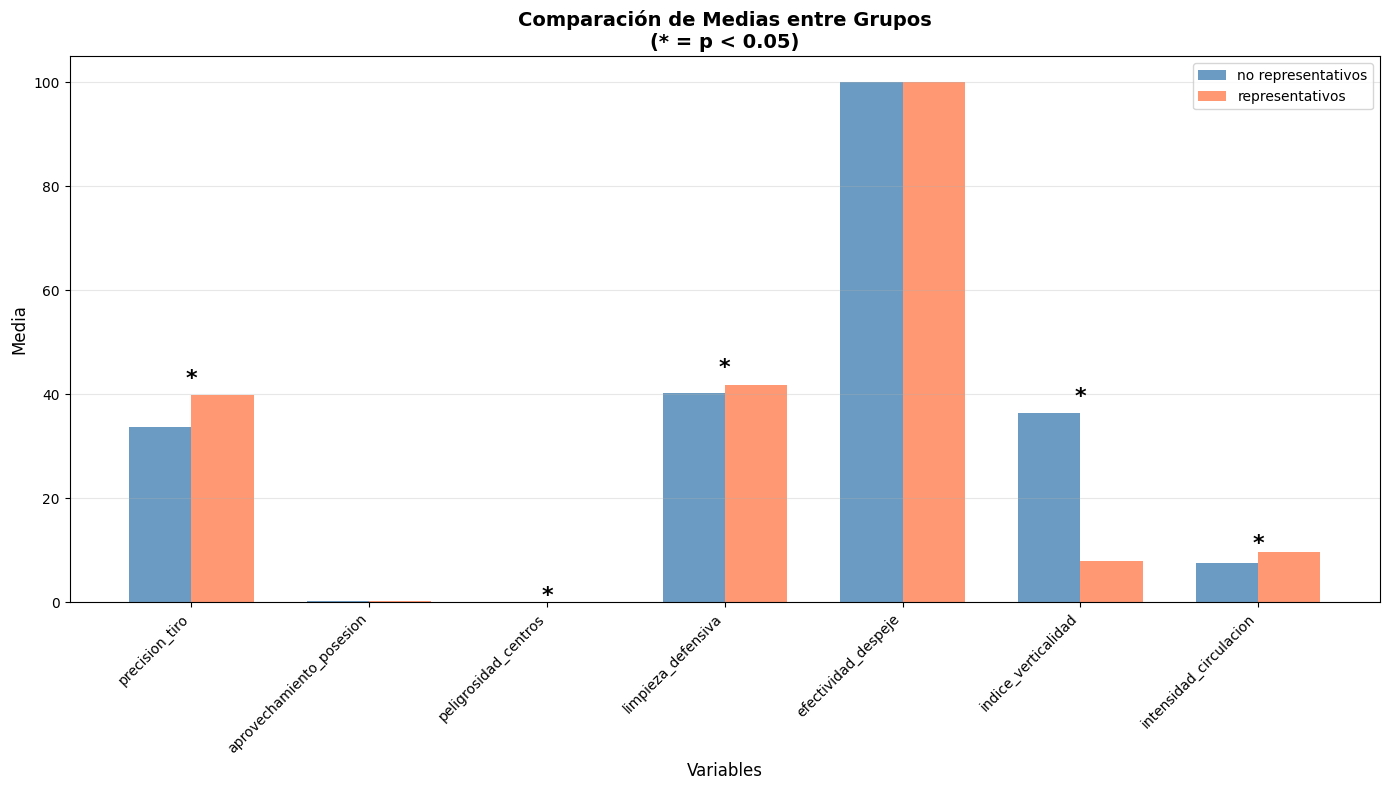

In [4]:
# List of columns to compare
columns_to_compare = [
    'precision_tiro',
    'aprovechamiento_posesion',
    #'aprovechamiento_posesion_peligroso',
    'peligrosidad_centros',
    #'precision_centros',
    'limpieza_defensiva',
    #'limpieza_defensiva_completa',
    'efectividad_despeje',
    'indice_verticalidad',
    #'verticalidad_efectiva',
    #'precision_verticalidad',
    'intensidad_circulacion',
    #'intensidad_circulacion_precisa'
]

# Perform t-tests and store results
results = []
for col in columns_to_compare:
    # Get data from both dataframes
    data1 = equip_no_rep_clean_kpi[col].dropna()
    data2 = equip_rep_clean_kpi[col].dropna()
    
    # Perform independent t-test
    t_stat, p_value = stats.ttest_ind(data1, data2)
    
    # Calculate means
    mean1 = data1.mean()
    mean2 = data2.mean()
    
    results.append({
        'Variable': col,
        'Mean_no_rep': mean1,
        'Mean_rep': mean2,
        'Difference': mean2 - mean1,
        't_statistic': t_stat,
        'p_value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# Create results dataframe
results_df = pd.DataFrame(results)
print(results_df)

# Save results to CSV
results_df.to_csv('t_test_results.csv', index=False)

# Create bar plot comparing means
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(columns_to_compare))
width = 0.35

means_no_rep = [results_df.loc[results_df['Variable'] == col, 'Mean_no_rep'].values[0] 
                for col in columns_to_compare]
means_rep = [results_df.loc[results_df['Variable'] == col, 'Mean_rep'].values[0] 
             for col in columns_to_compare]

bars1 = ax.bar(x - width/2, means_no_rep, width, label='no representativos', alpha=0.8)
bars2 = ax.bar(x + width/2, means_rep, width, label='representativos', alpha=0.8)

ax.set_xlabel('Variables', fontsize=12)
ax.set_ylabel('Media', fontsize=12)
ax.set_title('Comparación de Medias entre Grupos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(columns_to_compare, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a more detailed plot with significance markers
fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width/2, means_no_rep, width, label='no representativos', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, means_rep, width, label='representativos', alpha=0.8, color='coral')

# Add significance markers
for i, row in results_df.iterrows():
    if row['Significant'] == 'Yes':
        max_height = max(row['Mean_no_rep'], row['Mean_rep'])
        ax.text(i, max_height * 1.05, '*', ha='center', fontsize=16, fontweight='bold')

ax.set_xlabel('Variables', fontsize=12)
ax.set_ylabel('Media', fontsize=12)
ax.set_title('Comparación de Medias entre Grupos\n(* = p < 0.05)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(columns_to_compare, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_barplot_with_significance.png', dpi=300, bbox_inches='tight')
plt.show()



Análisis para: ENG
                   Variable  Mean_no_rep    Mean_rep       p_value Significant
0            precision_tiro    33.159464   38.801540  8.357973e-06         Yes
1  aprovechamiento_posesion     0.250739    0.263407  9.488975e-02          No
2      peligrosidad_centros     0.000737    0.000955  1.276863e-05         Yes
3        limpieza_defensiva    40.689903   40.388394  7.631244e-01          No
4       efectividad_despeje   100.000000  100.000000           NaN          No
5       indice_verticalidad    14.962131    7.899949  3.813807e-70         Yes
6    intensidad_circulacion     8.139754    9.213839  1.997690e-29         Yes


c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


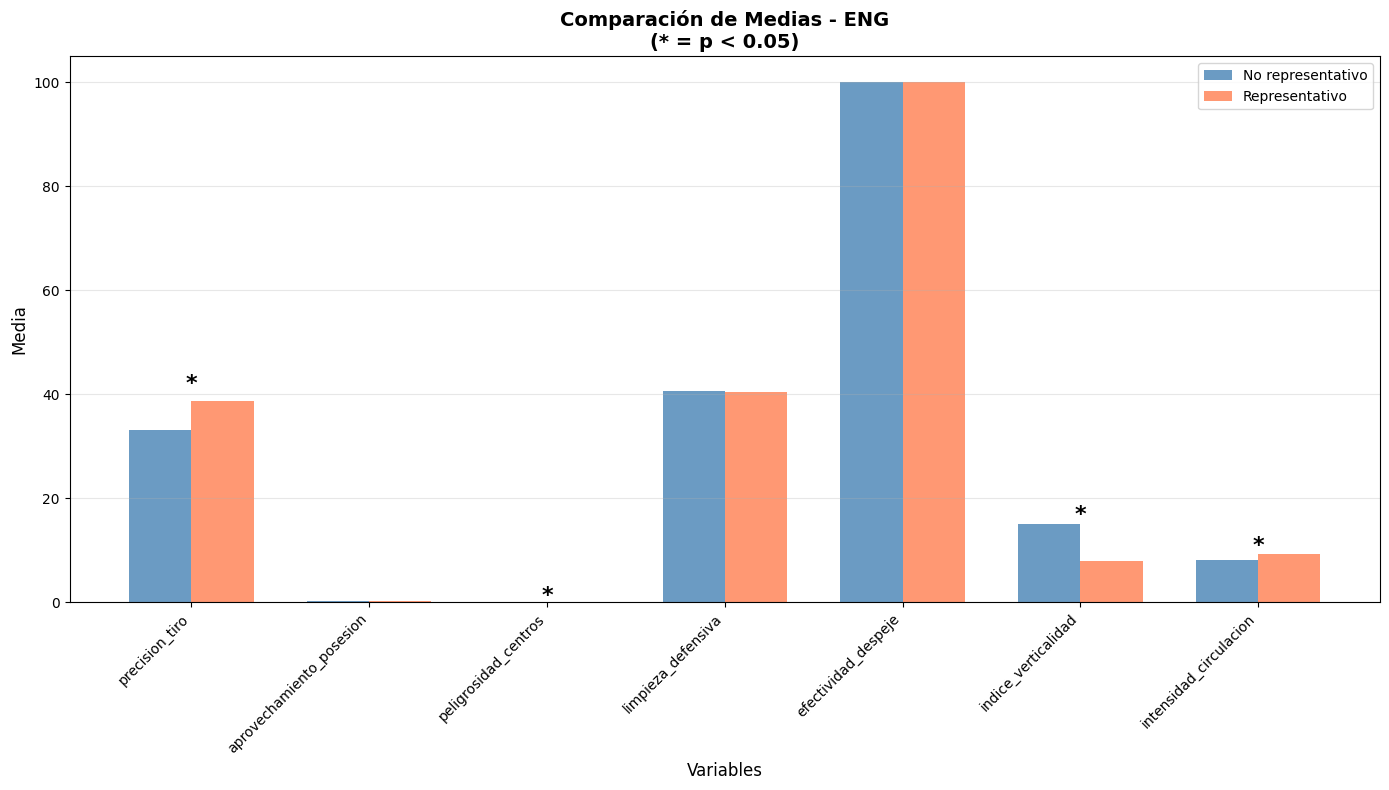


Análisis para: GER
                   Variable  Mean_no_rep    Mean_rep       p_value Significant
0            precision_tiro    32.179281   39.900840  1.467113e-04         Yes
1  aprovechamiento_posesion     0.311585    0.265191  7.180014e-04         Yes
2      peligrosidad_centros     0.000477    0.000987  1.725523e-08         Yes
3        limpieza_defensiva    42.226469   43.208693  5.195236e-01          No
4       efectividad_despeje   100.000000  100.000000           NaN          No
5       indice_verticalidad    15.769668    8.260160  1.043616e-44         Yes
6    intensidad_circulacion     8.713409    9.888266  2.321003e-13         Yes


c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


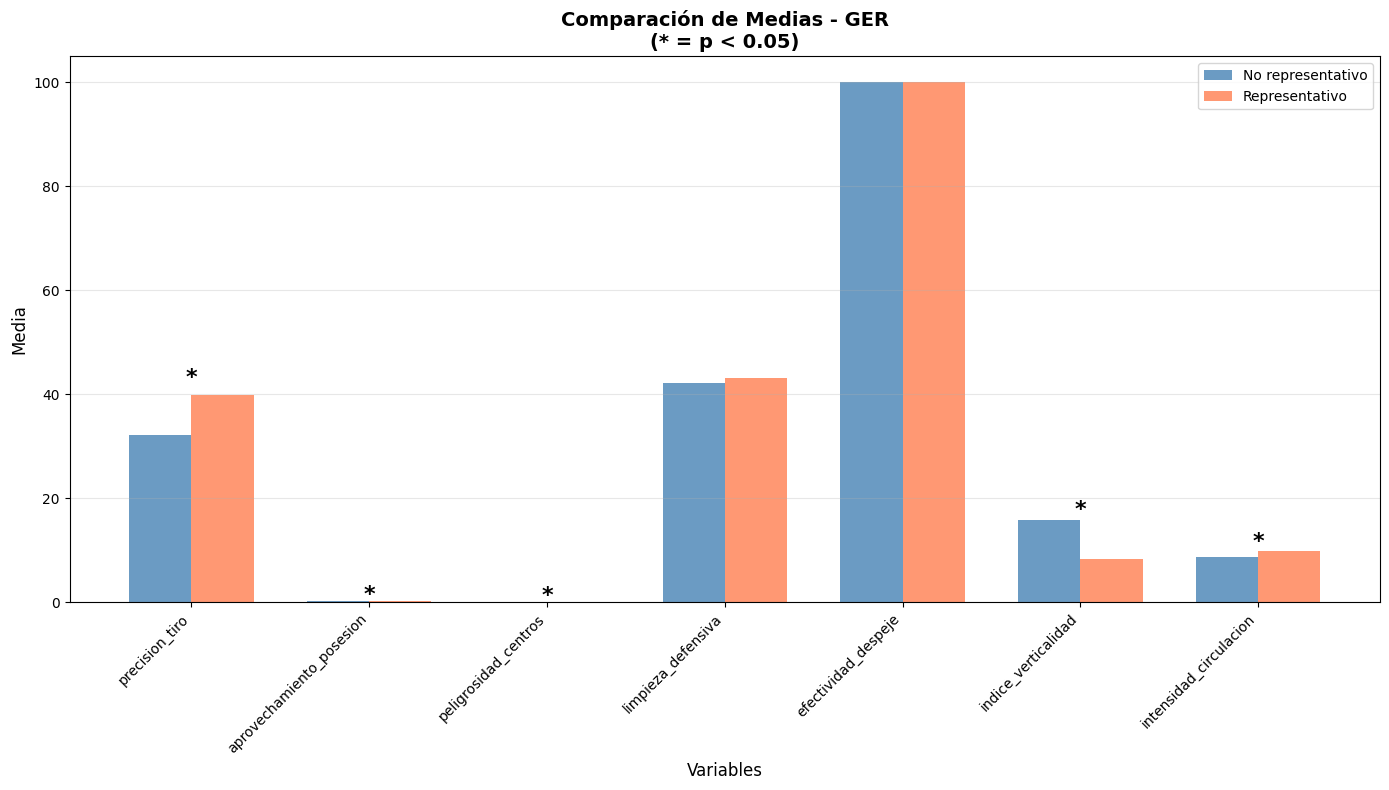


Análisis para: FRA
                   Variable  Mean_no_rep    Mean_rep       p_value Significant
0            precision_tiro    33.133167   42.487609  2.348336e-04         Yes
1  aprovechamiento_posesion     0.196653    0.272083  2.654803e-07         Yes
2      peligrosidad_centros     0.000025    0.001073  9.592785e-20         Yes
3        limpieza_defensiva    62.097770   44.202228  5.184579e-15         Yes
4       efectividad_despeje   100.000000  100.000000           NaN          No
5       indice_verticalidad    11.407767    6.365902  4.058678e-28         Yes
6    intensidad_circulacion     8.387751   10.332159  9.929459e-14         Yes


c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


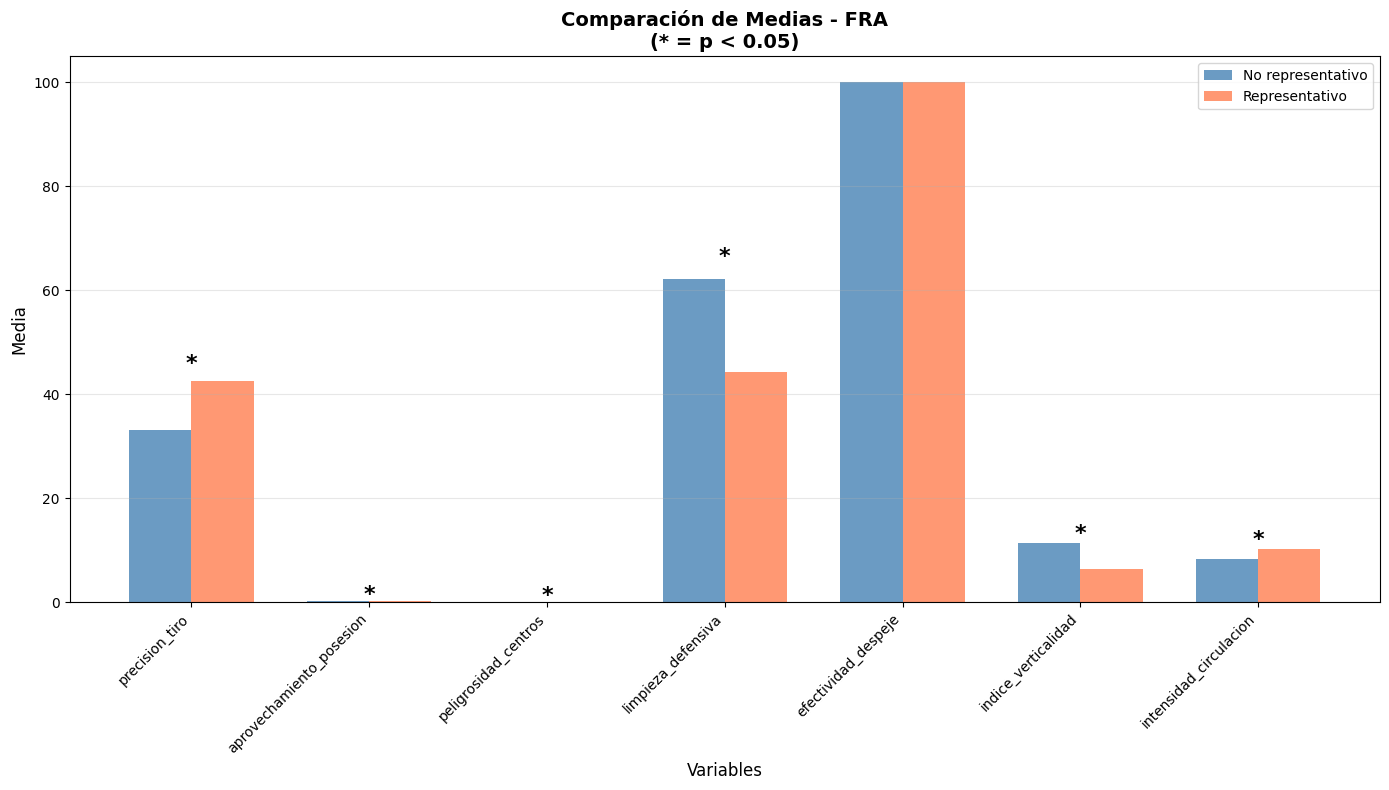


Análisis para: ESP
                   Variable  Mean_no_rep    Mean_rep       p_value Significant
0            precision_tiro    35.758679   40.068434  2.629346e-03         Yes
1  aprovechamiento_posesion     0.257254    0.270612  1.498579e-01          No
2      peligrosidad_centros     0.000023    0.000860  1.228522e-64         Yes
3        limpieza_defensiva    32.713536   42.154253  3.683100e-18         Yes
4       efectividad_despeje   100.000000  100.000000           NaN          No
5       indice_verticalidad    84.691981    8.111227  9.365861e-02          No
6    intensidad_circulacion     6.070922    9.807619  1.128480e-82         Yes


c:\Users\kimac\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


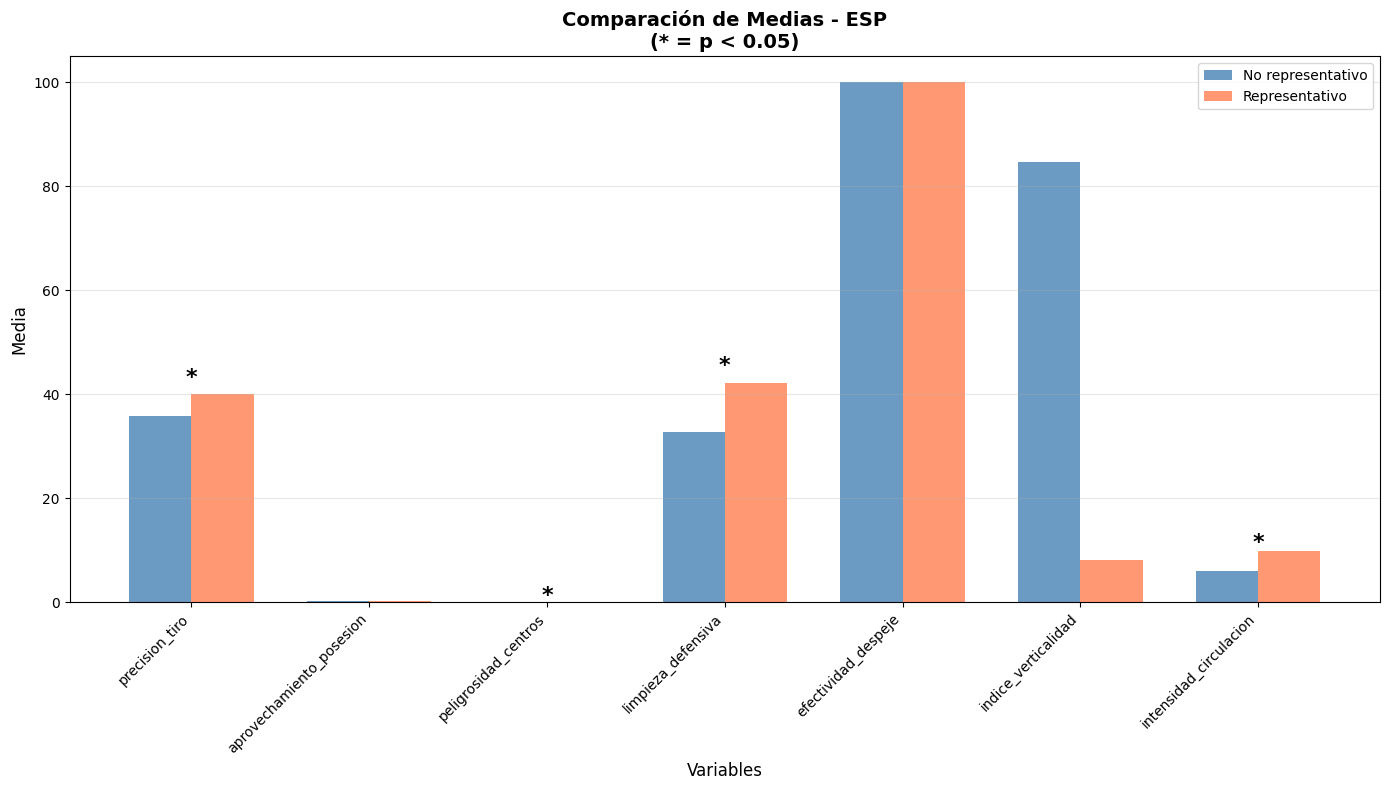


Resumen de resultados significativos por país:
   Country                  Variable  Mean_no_rep   Mean_rep       p_value
0      eng            precision_tiro    33.159464  38.801540  8.357973e-06
2      eng      peligrosidad_centros     0.000737   0.000955  1.276863e-05
5      eng       indice_verticalidad    14.962131   7.899949  3.813807e-70
6      eng    intensidad_circulacion     8.139754   9.213839  1.997690e-29
7      ger            precision_tiro    32.179281  39.900840  1.467113e-04
8      ger  aprovechamiento_posesion     0.311585   0.265191  7.180014e-04
9      ger      peligrosidad_centros     0.000477   0.000987  1.725523e-08
12     ger       indice_verticalidad    15.769668   8.260160  1.043616e-44
13     ger    intensidad_circulacion     8.713409   9.888266  2.321003e-13
14     fra            precision_tiro    33.133167  42.487609  2.348336e-04
15     fra  aprovechamiento_posesion     0.196653   0.272083  2.654803e-07
16     fra      peligrosidad_centros     0.000025   

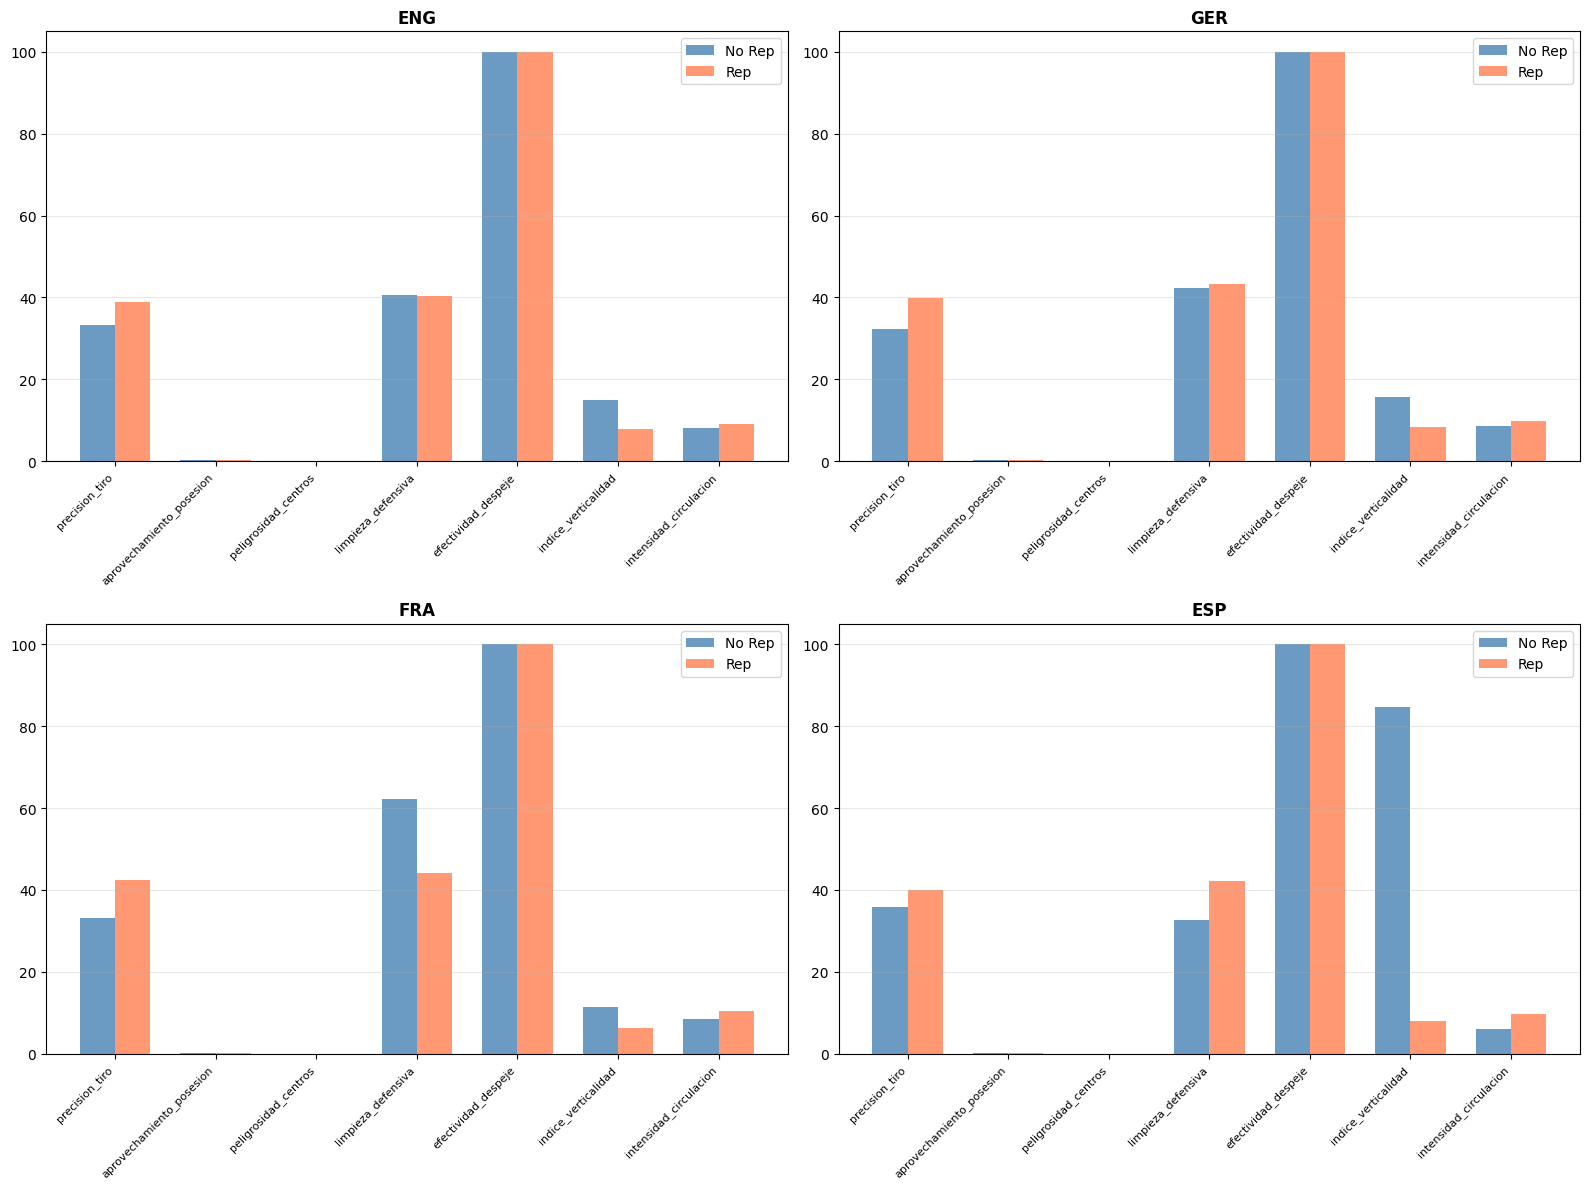

In [5]:
# Dictionary to store all results
all_country_results = {}

# Loop through each country
for country in ['eng', 'ger', 'fra', 'esp']:
    print(f"\n{'='*60}")
    print(f"Análisis para: {country.upper()}")
    print('='*60)
    
    # Perform t-tests and store results
    results = []
    
    for col in columns_to_compare:
        # Filter data by country
        data1 = equip_no_rep_clean_kpi.assign(Country=lambda x: x['slug'].str[0:3])[
            lambda x: x['Country'] == country
        ][col].dropna()
        
        data2 = equip_rep_clean_kpi.assign(Country=lambda x: x['slug'].str[0:3])[
            lambda x: x['Country'] == country
        ][col].dropna()
        
        # Check if we have enough data
        if len(data1) > 1 and len(data2) > 1:
            # Perform independent t-test
            t_stat, p_value = stats.ttest_ind(data1, data2)
            
            # Calculate means
            mean1 = data1.mean()
            mean2 = data2.mean()
            
            results.append({
                'Country': country,
                'Variable': col,
                'Mean_no_rep': mean1,
                'Mean_rep': mean2,
                'Difference': mean2 - mean1,
                'n_no_rep': len(data1),
                'n_rep': len(data2),
                't_statistic': t_stat,
                'p_value': p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No'
            })
        else:
            print(f"Warning: Not enough data for {col} in {country}")
    
    # Create results dataframe for this country
    results_df = pd.DataFrame(results)
    all_country_results[country] = results_df
    
    print(results_df[['Variable', 'Mean_no_rep', 'Mean_rep', 'p_value', 'Significant']])
    
    # Create bar plot for this country
    if len(results_df) > 0:
        fig, ax = plt.subplots(figsize=(14, 8))
        
        x = np.arange(len(results_df))
        width = 0.35
        
        means_no_rep = results_df['Mean_no_rep'].values
        means_rep = results_df['Mean_rep'].values
        
        bars1 = ax.bar(x - width/2, means_no_rep, width, label='No representativo', 
                      alpha=0.8, color='steelblue')
        bars2 = ax.bar(x + width/2, means_rep, width, label='Representativo', 
                      alpha=0.8, color='coral')
        
        # Add significance markers
        for i, row in results_df.iterrows():
            if row['Significant'] == 'Yes':
                max_height = max(row['Mean_no_rep'], row['Mean_rep'])
                ax.text(i, max_height * 1.05, '*', ha='center', 
                       fontsize=16, fontweight='bold')
        
        ax.set_xlabel('Variables', fontsize=12)
        ax.set_ylabel('Media', fontsize=12)
        ax.set_title(f'Comparación de Medias - {country.upper()}\n(* = p < 0.05)', 
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(results_df['Variable'], rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'comparison_barplot_{country}.png', dpi=300, bbox_inches='tight')
        plt.show()

# Combine all results into one dataframe
combined_results = pd.concat(all_country_results.values(), ignore_index=True)
combined_results.to_csv('t_test_results_by_country.csv', index=False)

print("\n" + "="*60)
print("Resumen de resultados significativos por país:")
print("="*60)
print(combined_results[combined_results['Significant'] == 'Yes'][
    ['Country', 'Variable', 'Mean_no_rep', 'Mean_rep', 'p_value']
])

# Optional: Create a summary plot showing all countries
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, country in enumerate(['eng', 'ger', 'fra', 'esp']):
    if country in all_country_results:
        results_df = all_country_results[country]
        
        x = np.arange(len(results_df))
        width = 0.35
        
        axes[idx].bar(x - width/2, results_df['Mean_no_rep'], width, 
                     label='No Rep', alpha=0.8, color='steelblue')
        axes[idx].bar(x + width/2, results_df['Mean_rep'], width, 
                     label='Rep', alpha=0.8, color='coral')
        
        axes[idx].set_title(f'{country.upper()}', fontsize=12, fontweight='bold')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(results_df['Variable'], rotation=45, ha='right', fontsize=8)
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_all_countries.png', dpi=300, bbox_inches='tight')
plt.show()